# Paderborn Bearing Fault Diagnosis â€” Main Pipeline

A complete end-to-end workflow for bearing fault classification using the Paderborn
University bearing dataset. This notebook ties together the four supporting modules
(`00_download_dataset`, `01_data_loader`, `02_dsp_features`, `03_ml_classification`)
into a single, reproducible pipeline.

**Dataset:** Paderborn University Bearing Data Center  
**Signals:** Phase currents (64 kHz), vibration (64 kHz), operating conditions (4 kHz)  
**Task:** 3-class fault classification â€” Healthy / Outer Race Fault / Inner Race Fault

In [ ]:
# =========================================================
# 0. Imports & Configuration
# =========================================================

# --- Standard library ---
import os
import sys
import glob
import importlib.util
import warnings
from datetime import datetime
from pathlib import Path

# --- Third-party core ---
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import stft

# --- scikit-learn ---
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- Other ML ---
import shap
import mlflow

# --- Deep learning (optional — 1D-CNN section guarded by HAS_TORCH) ---
try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except ImportError:
    torch = None
    nn    = None
    HAS_TORCH = False
    print("PyTorch not installed — 1D-CNN sections will be skipped.")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# --- Project modules (all live in utils/) ---
# inject=True pulls every public name into the notebook namespace automatically.
_BASE_DIR = Path(__file__).parent if '__file__' in dir() else Path().resolve()
_UTILS    = _BASE_DIR / "utils"

def _load_module(name: str, path: Path, inject: bool = True):
    """Load a local .py module and optionally inject its public names here."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    if inject:
        _public = {k: v for k, v in vars(mod).items() if not k.startswith('_')}
        globals().update(_public)
    return mod

_load_module("download_dataset",  _UTILS / "download_dataset.py")
_load_module("data_loader",       _UTILS / "data_loader.py")
_load_module("dsp_features",      _UTILS / "dsp_features.py")
_load_module("ml_classification", _UTILS / "ml_classification.py")
_load_module("plot_style",        _UTILS / "plot_style.py")

# Restore stdlib names that module-level imports may have shadowed
import os, sys, warnings
warnings.filterwarnings("ignore")

print("utils/ loaded: download_dataset | data_loader | dsp_features | ml_classification | plot_style")

In [11]:
# --- Constants (all tuneable values live here) ---
RANDOM_STATE = 42      # global seed
TEST_SIZE    = 0.20    # held-out test fraction
N_SPLITS     = 5       # cross-validation folds

# Signal-display
N_SHOW_SECONDS    = 0.1     # seconds of signal to display in time-domain plots

# Spectrum ranges  -  consistent across FFT and STFT for the same signal type
FFT_CURRENT_MAX_HZ    = 500
FFT_VIB_MAX_HZ        = 10000
STFT_CURRENT_MAX_HZ   = 500
STFT_VIB_MAX_HZ       = 10000
ENVELOPE_BAND         = (500, 10000)
ENVELOPE_CURRENT_BAND = (50, 5000)
ENVELOPE_MAX_HZ       = 300

# STFT
STFT_NPERSEG  = 2048
STFT_NOVERLAP = 1536

# Dataset selection
BEARING_SET = FULL_SET   # swap to MINIMAL_SET for real-damage-only (~2.4 GB)

# Operating condition filter
SETTING_FILTER  = 'N15_M07_F10'   #None for all conditions
USE_CURRENT     = True
USE_VIBRATION   = True

# DEV_MODE: cap signals loaded per bearing folder for fast iteration
N_SIGNALS_PER_BEARING = None

# Explainability
SHAP_SAMPLE_SIZE = 200

# --- Model improvement constants ---
GBT_N_ITER       = 30    # RandomizedSearchCV iterations for GBT tuning

# --- 1D-CNN toggle & constants ---
RUN_CNN          = False  # set False to skip sections 5e-5f (requires GPU)
CNN_SEGMENT_LEN  = 8192
CNN_OVERLAP      = 0.50
CNN_EPOCHS       = 30
CNN_BATCH_SIZE   = 64
CNN_LR           = 1e-3

# --- MLflow ---
RUN_MLFLOW        = True                        # set False to skip all MLflow logging
MLFLOW_EXPERIMENT = "paderborn-bearing-fault"   # experiment name in the tracking UI

PLOTS_DIR = _BASE_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

_set_name  = 'MINIMAL_SET' if BEARING_SET is MINIMAL_SET else 'FULL_SET'
_mat_root  = _BASE_DIR / "paderborn_data" / "mat"
_on_disk   = sum(1 for b in BEARING_SET if (_mat_root / b).is_dir())

print(f"Pipeline initialised   {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Base directory         {_BASE_DIR}")
print(f"Plots directory        {PLOTS_DIR}")
print(f"BEARING_SET            {_on_disk}/{len(BEARING_SET)} bearings on disk  ({_set_name})")
print(f"SETTING_FILTER         {SETTING_FILTER or 'ALL (4 conditions)'}")
print(f"N_SIGNALS_PER_BEARING  {N_SIGNALS_PER_BEARING}  (None = all)")
print(f"HAS_TORCH              {HAS_TORCH}")
print(f"RUN_CNN                {RUN_CNN}")
print(f"RUN_MLFLOW             {RUN_MLFLOW}")

Pipeline initialised   2026-03-12 14:20:27
Base directory         C:\8. ds
Plots directory        C:\8. ds\plots
BEARING_SET            32/32 bearings on disk  (FULL_SET)
SETTING_FILTER         N15_M07_F10
N_SIGNALS_PER_BEARING  None  (None = all)
HAS_TORCH              True
RUN_CNN                False
RUN_MLFLOW             True


## 1. Data Acquisition

`ensure_data` checks whether the required `.mat` files are already present and
downloads only the bearings listed in `MINIMAL_SET` if they are missing.
The returned path is the root directory that contains one sub-folder per bearing code.

In [12]:
# =========================================================
# 1. Data Acquisition
# =========================================================

mat_dir = ensure_data(BEARING_SET)
print(f"\nData directory: {mat_dir}")

# Locate .mat files for a healthy bearing (K001) as the exploration example
mat_files = glob.glob(str(mat_dir / 'K001' / '*.mat'))

if not mat_files:
    raise FileNotFoundError(
        f"No .mat files found under {mat_dir / 'K001'}. "
        "Re-run ensure_data or check the download path."
    )

EXAMPLE_FILE = mat_files[0]
print(f"Example file  : {os.path.basename(EXAMPLE_FILE)}")
print(f"Files available: {len(mat_files)}")

Dataset ready: all 32 bearings found in C:\8. ds\paderborn_data\mat

Data directory: C:\8. ds\paderborn_data\mat
Example file  : N09_M07_F10_K001_1.mat
Files available: 80


## 2. Exploratory Data Analysis

Load one representative `.mat` file and inspect its metadata and signal statistics.
This confirms the data loaded correctly and surfaces the operating conditions
(speed, torque, force) that will become important for stratification later.
Bearing characteristic frequencies are calculated from the measured shaft speed
and will be used to interpret spectral plots in Section 7.

In [13]:
# =========================================================
# 2. Exploratory Data Analysis
# =========================================================

sig = load_mat_file(EXAMPLE_FILE)

print(f"Bearing        : {sig.bearing_code}")
print(f"Condition      : {sig.label_name}  (class {sig.label_3class})")
print(f"Damage origin  : {sig.damage_origin}")
print(f"Operating setting: {sig.setting}")

print("\n--- Signal Info ---")
print(f"  Sampling rate : {sig.fs} Hz")
print(f"  Duration      : {sig.duration} s")
print(f"  Current 1   shape={sig.phase_current_1.shape}  "
      f"RMS={np.sqrt(np.mean(sig.phase_current_1**2)):.4f}")
print(f"  Current 2   shape={sig.phase_current_2.shape}  "
      f"RMS={np.sqrt(np.mean(sig.phase_current_2**2)):.4f}")
print(f"  Vibration   shape={sig.vibration.shape}  "
      f"RMS={np.sqrt(np.mean(sig.vibration**2)):.4f}")

print("\n--- Operating Conditions ---")
print(f"  Speed       : {sig.speed.mean():.1f} rpm")
print(f"  Torque      : {sig.torque.mean():.3f} Nm")
print(f"  Force       : {sig.force.mean():.1f} N")
print(f"  Temperature : {sig.temperature.mean():.1f} Â°C")

Bearing        : K001
Condition      : Healthy  (class 0)
Damage origin  : healthy
Operating setting: N09_M07_F10

--- Signal Info ---
  Sampling rate : 64000 Hz
  Duration      : 4.0 s
  Current 1   shape=(256823,)  RMS=1.6567
  Current 2   shape=(256823,)  RMS=1.6681
  Vibration   shape=(256823,)  RMS=0.3676

--- Operating Conditions ---
  Speed       : 899.7 rpm
  Torque      : 1.200 Nm
  Force       : 1025.9 N
  Temperature : 46.9 Â°C


In [14]:
# --- 2a. Bearing Characteristic Frequencies ---
# Derived from geometry; used as reference markers in spectral plots.

char_freqs = calc_characteristic_frequencies(sig.speed.mean())

print("Bearing characteristic frequencies:")
for name, f in char_freqs.items():
    print(f"  {name:6s}: {f:.2f} Hz")

Bearing characteristic frequencies:
  shaft_freq: 15.00 Hz
  BPFO  : 45.80 Hz
  BPFI  : 74.16 Hz
  BSF   : 29.94 Hz
  FTF   : 5.72 Hz


## 3. Preprocessing Pipeline â€” DSP Feature Extraction

Raw time-series are transformed into a fixed-length feature vector per segment.
Four complementary feature groups capture different fault signatures:

| Group | Domain | Captures |
|---|---|---|
| Time-domain | Time | Amplitude statistics (RMS, kurtosis, crest factor â€¦) |
| Frequency-domain | Frequency | Spectral centroid, bandwidth, harmonic ratios |
| WPD (Wavelet Packet) | Time-frequency | Sub-band energy distribution |
| Envelope | Frequency (demodulated) | Fault impulse repetition rates |

Each feature group is demonstrated on the example signal; the final cell runs
`extract_all_features` which combines all groups into one vector.

In [15]:
# =========================================================
# 3. Preprocessing Pipeline
# =========================================================

# --- 3a. Time-Domain Features (Phase Current 1) ---
td = time_domain_features(sig.phase_current_1)
print("Time-domain features:")
for k, v in td.items():
    print(f"  {k:<25}: {v:.6f}")

Time-domain features:
  mean                     : 0.023506
  std                      : 1.656556
  rms                      : 1.656722
  peak                     : 2.877041
  peak_to_peak             : 5.730664
  skewness                 : 0.006718
  kurtosis                 : 1.506477
  crest_factor             : 1.736586
  shape_factor             : 1.112840
  impulse_factor           : 1.932544
  clearance_factor         : 2.119184
  energy                   : 704909.462866
  entropy                  : 2.150155


In [16]:
# --- 3b. Frequency-Domain Features ---
fd = frequency_domain_features(sig.phase_current_1, sig.fs)
print("Frequency-domain features:")
for k, v in fd.items():
    print(f"  {k:<25}: {v:.6f}")

Frequency-domain features:
  spectral_centroid        : 85.554516
  spectral_variance        : 518637.396506
  spectral_std             : 720.164840
  spectral_skewness        : 31.672122
  spectral_kurtosis        : 1101.774745
  total_spectral_energy    : 0.175985
  peak_frequency           : 62.500000
  peak_amplitude           : 1.983097
  energy_0_500Hz           : 0.175714
  energy_500_2000Hz        : 0.000008
  energy_2000_8000Hz       : 0.000032
  energy_8000_16000Hz      : 0.000114


In [17]:
# --- 3c. Wavelet Packet Decomposition Features ---
wpd = wavelet_packet_features(sig.phase_current_1)
print(f"WPD features (first 8 of {len(wpd)}):")
for k, v in list(wpd.items())[:8]:
    print(f"  {k:<25}: {v:.6f}")

WPD features (first 8 of 17):
  energy_band_0            : 703970.866394
  energy_band_1            : 77.554972
  energy_band_2            : 66.528441
  energy_band_3            : 298.172475
  energy_band_4            : 296.275205
  energy_band_5            : 66.296724
  energy_band_6            : 64.751766
  energy_band_7            : 135.434299


In [18]:
# --- 3d. Envelope Analysis (Vibration) ---
# Bandpass â†’ Hilbert â†’ magnitude spectrum; fault frequencies appear as peaks.
env_freqs_vib, env_spec_vib = envelope_analysis(sig.vibration, sig.fs, band=ENVELOPE_BAND)

print("Envelope amplitudes at characteristic frequencies (vibration):")
for name, f_char in char_freqs.items():
    if f_char > 0:
        mask = (env_freqs_vib >= f_char - 2) & (env_freqs_vib <= f_char + 2)
        if np.any(mask):
            peak = np.max(env_spec_vib[mask])
            print(f"  {name:6s} ({f_char:.1f} Hz): {peak:.6f}")

Envelope amplitudes at characteristic frequencies (vibration):
  shaft_freq (15.0 Hz): 0.008646
  BPFO   (45.8 Hz): 0.020081
  BPFI   (74.2 Hz): 0.002278
  BSF    (29.9 Hz): 0.002896
  FTF    (5.7 Hz): 0.010025


In [19]:
# --- 3e. Full Feature Vector ---
all_feats = extract_all_features(sig.phase_current_1, sig.fs, 'current', char_freqs)
print(f"Total features extracted per segment: {len(all_feats)}")

Total features extracted per segment: 57


### 3f. Batch Feature Extraction

Load every bearing folder under `mat_dir`, optionally filtered to `SETTING_FILTER`.
When `SETTING_FILTER = None` all four operating conditions are used, giving
**~15 bearings Ã -  4 conditions Ã -  20 signals = ~1 200 samples**.

**Speed normalisation** is applied after raw feature extraction so that the
feature matrix is condition-invariant:

| Feature group | Raw units | Normalised to |
|---|---|---|
| `fd_spectral_centroid`, `fd_peak_frequency`, `fd_spectral_std` | Hz | orders (Ã· f_shaft) |
| `fd_spectral_variance` | HzÂ^2 | ordersÂ^2 (Ã· f_shaftÂ^2) |
| Envelope (`env_*`) | amplitude | *unchanged* â€” already speed-invariant because they are extracted AT the characteristic frequencies computed from the actual RPM |
| Time-domain, WPD ratios, WPD entropy | dimensionless | *unchanged* |

Runtime: 4â€“12 minutes depending on hardware (wavelet and envelope steps dominate).

In [20]:
# --- 3f-i. Load all bearing signals (one operating condition) ---
# Iterate only BEARING_SET â€” never stray into extra folders that may exist on disk.
all_signals: list = []
for bearing_code in BEARING_SET:
    bearing_folder = mat_dir / bearing_code
    if not bearing_folder.is_dir():
        print(f"  WARNING: {bearing_code} not found on disk â€” skipping")
        continue
    sigs = load_dataset(str(bearing_folder), setting_filter=SETTING_FILTER)
    if N_SIGNALS_PER_BEARING is not None:
        sigs = sigs[:N_SIGNALS_PER_BEARING]
    all_signals.extend(sigs)

_actual_bearings = len(set(s.bearing_code for s in all_signals))
print(f"\nLoaded {len(all_signals)} signals  "
      f"({_actual_bearings}/{len(BEARING_SET)} bearings available, "
      f"up to {N_SIGNALS_PER_BEARING or 20} signals each)")
print("Class distribution:")
for label, name in enumerate(['Healthy', 'OR_damage', 'IR_damage']):
    n = sum(1 for s in all_signals if s.label_3class == label)
    print(f"  {label} -- {name}: {n}")

  Loaded N15_M07_F10_K001_1.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_10.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_11.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_12.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_13.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_14.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_15.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_16.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_17.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_18.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_19.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_2.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_20.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_3.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_4.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_5.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_6.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_7.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_8.mat -> Healthy (K001)
  Loaded N15_M07_F10_K001_9.mat -> Heal

In [ ]:
# --- 3f-ii. Extract features -> build X, y, groups matrices ---
# Feature extraction is expensive (4-12 min). Results are cached to disk keyed by
# the parameters that affect the output. Re-run is triggered automatically when
# BEARING_SET, SETTING_FILTER, USE_CURRENT, USE_VIBRATION, or N_SIGNALS_PER_BEARING change.

import hashlib, pickle

_cache_key = hashlib.md5(
    f"{sorted(BEARING_SET)}{SETTING_FILTER}{USE_CURRENT}{USE_VIBRATION}"
    f"{N_SIGNALS_PER_BEARING}".encode()
).hexdigest()[:12]
_cache_path = _BASE_DIR / f".feature_cache_{_cache_key}.pkl"

if _cache_path.exists():
    print(f"Loading cached features from {_cache_path.name} ...")
    with open(_cache_path, "rb") as _f:
        _cache = pickle.load(_f)
    X             = _cache["X"]
    y             = _cache["y"]
    groups        = _cache["groups"]
    feature_names = _cache["feature_names"]
    print(f"Loaded from cache: {X.shape}")

else:
    print("No cache found  -  computing features (this may take 4-12 min) ...")

    def _normalize_freq_features(feats: dict, f_shaft: float) -> dict:
        """Convert absolute-frequency features to speed-invariant orders.

        Dividing Hz features by f_shaft (rpm/60) yields orders  -  multiples of
        the shaft rotation frequency  -  so the same fault pattern produces the same
        feature value regardless of operating speed.

        Args:
            feats:   Feature dictionary returned by extract_features_from_bearing.
            f_shaft: Shaft rotation frequency in Hz (= rpm / 60).

        Returns:
            Same dict with frequency features replaced by order-domain equivalents.
        """
        hz_suffixes = ('_spectral_centroid', '_spectral_std', '_peak_frequency')
        for k in list(feats):
            if any(k.endswith(s) for s in hz_suffixes):
                feats[k] = feats[k] / (f_shaft + 1e-10)
        for k in list(feats):
            if k.endswith('_spectral_variance'):
                feats[k] = feats[k] / (f_shaft**2 + 1e-10)
        return feats

    feature_list: list = []
    label_list:   list = []
    groups:       list = []

    for sig_i in tqdm(all_signals, desc="Extracting features", unit="signal"):
        rpm = OPERATING_CONDITIONS[sig_i.setting]['speed_rpm']
        char_freqs_i = calc_characteristic_frequencies(rpm)
        f_shaft_i    = rpm / 60

        feats = extract_features_from_bearing(
            sig_i,
            use_current=USE_CURRENT,
            use_vibration=USE_VIBRATION,
            characteristic_freqs=char_freqs_i,
        )
        feats = _normalize_freq_features(feats, f_shaft_i)

        feature_list.append(list(feats.values()))
        label_list.append(sig_i.label_3class)
        groups.append(sig_i.bearing_code)

    feature_names = list(feats.keys())
    X      = np.array(feature_list, dtype=np.float32)
    y      = np.array(label_list,   dtype=np.int64)
    groups = np.array(groups)

    with open(_cache_path, "wb") as _f:
        pickle.dump({"X": X, "y": y, "groups": groups,
                     "feature_names": feature_names}, _f)
    print(f"Features cached to {_cache_path.name}")

print(f"Feature matrix : {X.shape}  ({len(feature_names)} features per signal)")
print(f"Label vector   : {y.shape}  classes={np.bincount(y)}")
print(f"Unique bearings: {np.unique(groups)}")

label_encoder = LabelEncoder().fit(y)
class_names   = ['Healthy', 'OR_damage', 'IR_damage']
display(
    pd.Series(y)
      .map(dict(enumerate(class_names)))
      .value_counts()
      .rename("count")
      .to_frame()
)

No cache found  -  computing features (this may take 4-12 min) ...


Extracting features:  32%|███▏      | 202/640 [02:12<04:12,  1.74signal/s]

### 3g. DSP Signal Visualisations â€” Healthy vs Damaged

Each plot shows **K001 (Healthy)** on the left and **KA04 (Outer Race Fault)** on
the right, under identical operating conditions. This side-by-side layout makes
fault signatures immediately visible across all five analysis domains.

In [ ]:
# --- 3h. Load damaged bearing example (KA04 â€” Outer Race Fault) ---
# KA04 is a real fatigue-induced outer race damage bearing from MINIMAL_SET.
# When SETTING_FILTER is None, pick any available file; otherwise match the filter.
_dmg_pattern = (
    str(mat_dir / 'KA04' / f'*{SETTING_FILTER}*.mat')
    if SETTING_FILTER
    else str(mat_dir / 'KA04' / '*.mat')
)
_dmg_files = glob.glob(_dmg_pattern)
if not _dmg_files:
    raise FileNotFoundError(
        f"No KA04 files found for setting {SETTING_FILTER}. "
        "Check mat_dir or run ensure_data."
    )

sig_dmg = load_mat_file(_dmg_files[0])
char_freqs_dmg = calc_characteristic_frequencies(sig_dmg.speed.mean())

print(f"Damaged bearing  : {sig_dmg.bearing_code}")
print(f"Condition        : {sig_dmg.label_name}  (class {sig_dmg.label_3class})")
print(f"Damage origin    : {sig_dmg.damage_origin}")
print(f"Operating setting: {sig_dmg.setting}")
print(f"Speed            : {sig_dmg.speed.mean():.1f} rpm")
print("\nCharacteristic frequencies:")
for name, f in char_freqs_dmg.items():
    print(f"  {name:6s}: {f:.2f} Hz")

Damaged bearing  : KA04
Condition        : OR_damage  (class 1)
Damage origin    : real
Operating setting: N15_M07_F10
Speed            : 1499.8 rpm

Characteristic frequencies:
  shaft_freq: 25.00 Hz
  BPFO  : 76.35 Hz
  BPFI  : 123.63 Hz
  BSF   : 49.91 Hz
  FTF   : 9.54 Hz


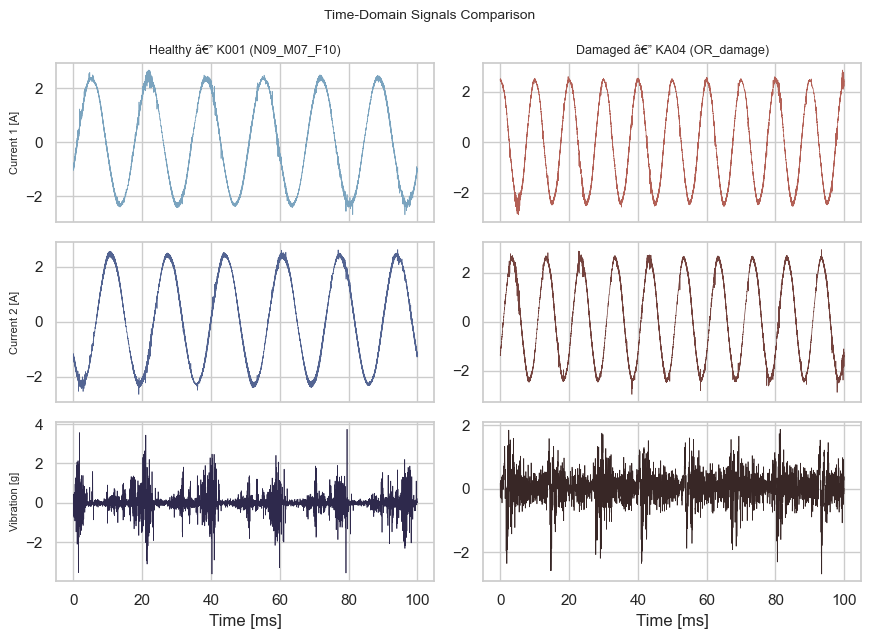

In [ ]:
# --- 3g-i. Time-Domain Signals Comparison ---
_n_show = int(N_SHOW_SECONDS * sig.fs)
_t_ms   = sig.time_64k[:_n_show] * 1000   # ms

_rows = [
    (sig.phase_current_1, sig_dmg.phase_current_1, "Current 1 [A]", C1, D1),
    (sig.phase_current_2, sig_dmg.phase_current_2, "Current 2 [A]", C2, D2),
    (sig.vibration,       sig_dmg.vibration,       "Vibration [g]", C3, D3),
]

fig, axes = plt.subplots(3, 2, figsize=(9, 6.5), sharex=True)
axes[0, 0].set_title(f"Healthy â€” {sig.bearing_code} ({sig.setting})", fontsize=9)
axes[0, 1].set_title(f"Damaged â€” {sig_dmg.bearing_code} ({sig_dmg.label_name})", fontsize=9)

for row, (h_sig, d_sig, ylabel, h_col, d_col) in enumerate(_rows):
    axes[row, 0].plot(_t_ms, h_sig[:_n_show], lw=0.5, color=h_col)
    axes[row, 1].plot(_t_ms, d_sig[:_n_show], lw=0.5, color=d_col)
    axes[row, 0].set_ylabel(ylabel, fontsize=8)

for col in range(2):
    axes[2, col].set_xlabel("Time [ms]")

fig.suptitle("Time-Domain Signals Comparison", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_time_domain_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

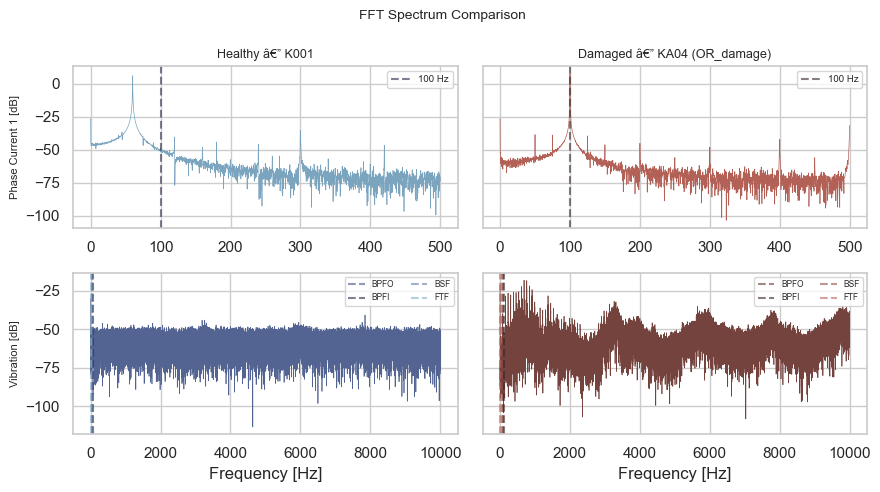

In [ ]:
# --- 3g-ii. FFT Spectrum Comparison ---
def _fft_db(signal, fs):
    N = len(signal)
    freqs = np.fft.fftfreq(N, 1 / fs)[: N // 2]
    mag   = np.abs(np.fft.fft(signal))[: N // 2] * 2 / N
    return freqs, 20 * np.log10(mag + 1e-10)

_fc_h, _mc_h = _fft_db(sig.phase_current_1,     sig.fs)
_fv_h, _mv_h = _fft_db(sig.vibration,            sig.fs)
_fc_d, _mc_d = _fft_db(sig_dmg.phase_current_1,  sig_dmg.fs)
_fv_d, _mv_d = _fft_db(sig_dmg.vibration,         sig_dmg.fs)

fig, axes = plt.subplots(2, 2, figsize=(9, 5), sharey='row')
axes[0, 0].set_title(f"Healthy â€” {sig.bearing_code}", fontsize=9)
axes[0, 1].set_title(f"Damaged â€” {sig_dmg.bearing_code} ({sig_dmg.label_name})", fontsize=9)

# Row 0: Phase Current 1
for ax, freqs, mag, color, vcolor in [
    (axes[0, 0], _fc_h, _mc_h, C1, C3),
    (axes[0, 1], _fc_d, _mc_d, D1, D3),
]:
    mask = freqs <= FFT_CURRENT_MAX_HZ
    ax.plot(freqs[mask], mag[mask], lw=0.5, color=color)
    ax.axvline(x=100, color=vcolor, ls='--', alpha=0.6, label='100 Hz')
    ax.legend(fontsize=7)

# Row 1: Vibration
for ax, freqs, mag, color, cf, fc in [
    (axes[1, 0], _fv_h, _mv_h, C2, char_freqs,     FAULT_COLORS),
    (axes[1, 1], _fv_d, _mv_d, D2, char_freqs_dmg, FAULT_COLORS_DMG),
]:
    mask = freqs <= FFT_VIB_MAX_HZ
    ax.plot(freqs[mask], mag[mask], lw=0.5, color=color)
    for name, f in cf.items():
        if name in fc:
            ax.axvline(x=f, color=fc[name], ls='--', alpha=0.6, label=name)
    ax.legend(fontsize=6, ncol=2)

axes[0, 0].set_ylabel("Phase Current 1 [dB]", fontsize=8)
axes[1, 0].set_ylabel("Vibration [dB]",        fontsize=8)
for col in range(2):
    axes[1, col].set_xlabel("Frequency [Hz]")

fig.suptitle("FFT Spectrum Comparison", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_fft_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

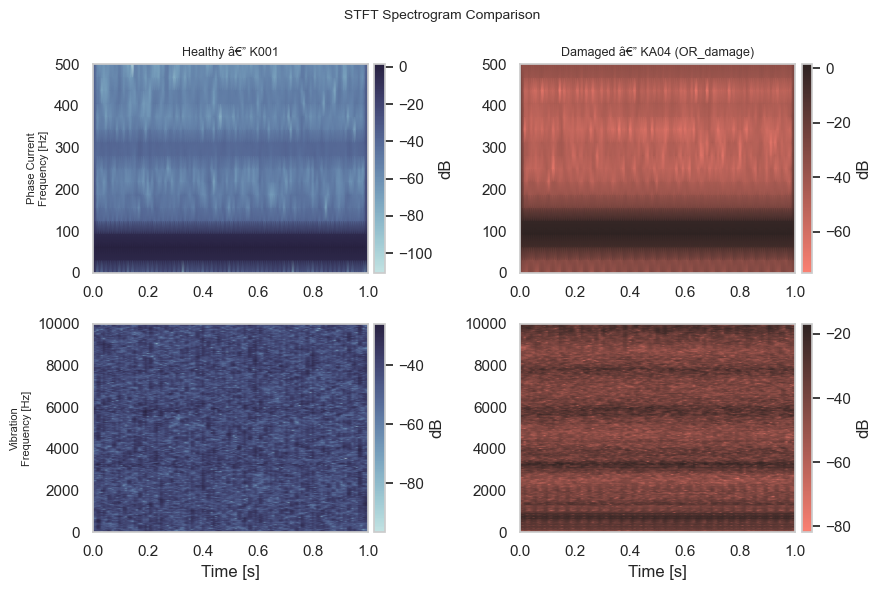

In [ ]:
# --- 3g-iii. STFT Spectrogram Comparison ---
# Use a fixed-duration segment so STFT and CWT use the same time window.
_STFT_DUR_S = 1.0
_n_stft = int(_STFT_DUR_S * sig.fs)

# Truncate to fixed duration
_c1_h_stft  = sig.phase_current_1[:_n_stft]
_vib_h_stft = sig.vibration[:_n_stft]
_c1_d_stft  = sig_dmg.phase_current_1[:_n_stft]
_vib_d_stft = sig_dmg.vibration[:_n_stft]

# STFT
_f_s, _t_s, _Zch = stft(
    _c1_h_stft,
    fs=sig.fs,
    nperseg=STFT_NPERSEG,
    noverlap=STFT_NOVERLAP
)

_f_v, _t_v, _Zvh = stft(
    _vib_h_stft,
    fs=sig.fs,
    nperseg=STFT_NPERSEG,
    noverlap=STFT_NOVERLAP
)

_, _, _Zcd = stft(
    _c1_d_stft,
    fs=sig_dmg.fs,
    nperseg=STFT_NPERSEG,
    noverlap=STFT_NOVERLAP
)

_, _, _Zvd = stft(
    _vib_d_stft,
    fs=sig_dmg.fs,
    nperseg=STFT_NPERSEG,
    noverlap=STFT_NOVERLAP
)

# Frequency-axis masks
_mf_c = _f_s <= STFT_CURRENT_MAX_HZ
_mf_v = _f_v <= STFT_VIB_MAX_HZ

# Plot
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes[0, 0].set_title(f"Healthy â€” {sig.bearing_code}", fontsize=9)
axes[0, 1].set_title(f"Damaged â€” {sig_dmg.bearing_code} ({sig_dmg.label_name})", fontsize=9)

for (ax, t, f, f_mask, Z, cmap) in [
    (axes[0, 0], _t_s, _f_s, _mf_c, _Zch, CMAP),
    (axes[0, 1], _t_s, _f_s, _mf_c, _Zcd, CMAP_DMG),
    (axes[1, 0], _t_v, _f_v, _mf_v, _Zvh, CMAP),
    (axes[1, 1], _t_v, _f_v, _mf_v, _Zvd, CMAP_DMG),
]:
    C = 20 * np.log10(np.abs(Z[f_mask]) + 1e-10)

    # Trim time axis to match C columns (scipy may append one extra boundary frame)
    t_plot = t[:C.shape[1]]

    pcm = ax.pcolormesh(
        t_plot,
        f[f_mask],
        C,
        cmap=cmap,
        shading='gouraud'
    )
    fig.colorbar(pcm, ax=ax, label='dB', pad=0.02)

    # Optional: make the visible x-axis exactly match the fixed-duration window
    ax.set_xlim(0, _STFT_DUR_S)

axes[0, 0].set_ylabel("Phase Current\nFrequency [Hz]", fontsize=8)
axes[1, 0].set_ylabel("Vibration\nFrequency [Hz]", fontsize=8)

for col in range(2):
    axes[1, col].set_xlabel("Time [s]")

fig.suptitle("STFT Spectrogram Comparison", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_stft_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

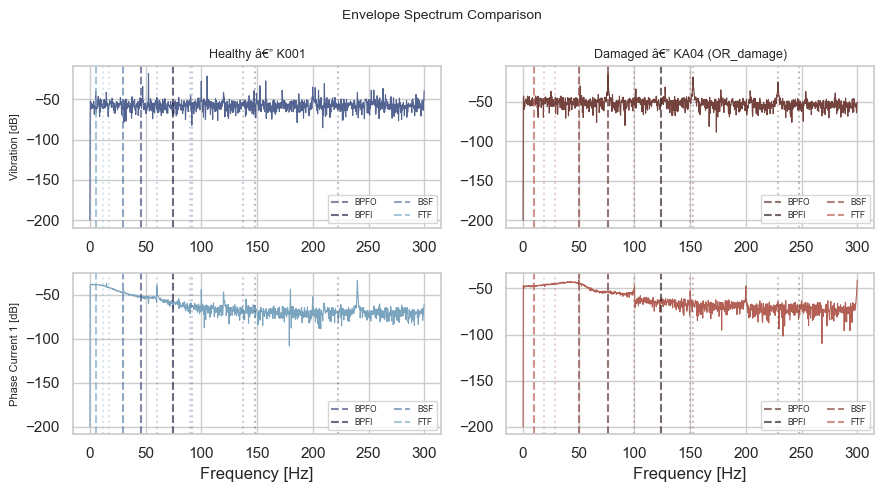

In [ ]:
# --- 3g-iv. Envelope Spectrum Comparison ---
# Recompute envelopes for both conditions (env_freqs_vib/env_spec_vib from sec3-envelope
# are for sig only; compute damaged and current channel fresh here).
_efv_h, _esv_h = env_freqs_vib, env_spec_vib   # healthy vibration (from sec3-envelope)
_efv_d, _esv_d = envelope_analysis(sig_dmg.vibration,       sig_dmg.fs, band=ENVELOPE_BAND)
_efc_h, _esc_h = envelope_analysis(sig.phase_current_1,     sig.fs,     band=ENVELOPE_CURRENT_BAND)
_efc_d, _esc_d = envelope_analysis(sig_dmg.phase_current_1, sig_dmg.fs, band=ENVELOPE_CURRENT_BAND)

def _env_axes(ax, freqs, spec, cf_dict, fc_dict, color):
    mask = freqs <= ENVELOPE_MAX_HZ
    ax.plot(freqs[mask], 20 * np.log10(spec[mask] + 1e-10), lw=0.8, color=color)
    for name, f in cf_dict.items():
        if name in fc_dict and f <= ENVELOPE_MAX_HZ:
            ax.axvline(x=f, color=fc_dict[name], ls='--', alpha=0.7, label=name)
            for h in [2, 3]:
                if f * h <= ENVELOPE_MAX_HZ:
                    ax.axvline(x=f * h, color=fc_dict[name], ls=':', alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

fig, axes = plt.subplots(2, 2, figsize=(9, 5))
axes[0, 0].set_title(f"Healthy â€” {sig.bearing_code}", fontsize=9)
axes[0, 1].set_title(f"Damaged â€” {sig_dmg.bearing_code} ({sig_dmg.label_name})", fontsize=9)

_env_axes(axes[0, 0], _efv_h, _esv_h, char_freqs,     FAULT_COLORS,     C2)
_env_axes(axes[0, 1], _efv_d, _esv_d, char_freqs_dmg, FAULT_COLORS_DMG, D2)
_env_axes(axes[1, 0], _efc_h, _esc_h, char_freqs,     FAULT_COLORS,     C1)
_env_axes(axes[1, 1], _efc_d, _esc_d, char_freqs_dmg, FAULT_COLORS_DMG, D1)

axes[0, 0].set_ylabel("Vibration [dB]",       fontsize=8)
axes[1, 0].set_ylabel("Phase Current 1 [dB]", fontsize=8)
for col in range(2):
    axes[1, col].set_xlabel("Frequency [Hz]")

fig.suptitle("Envelope Spectrum Comparison", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_envelope_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

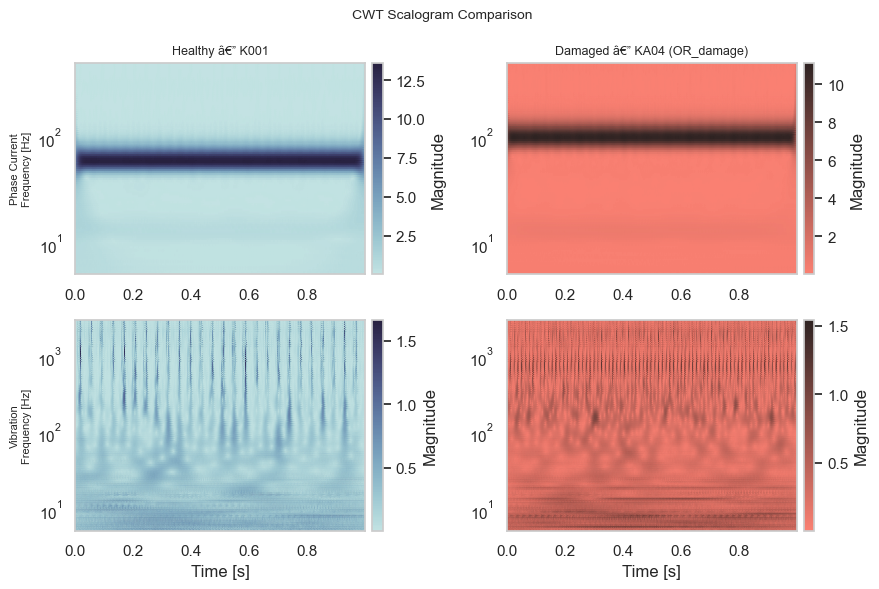

In [ ]:
# --- 3g-v. CWT Scalogram Comparison ---
# Complex Morlet CWT: same time-frequency principle as STFT but with
# adaptive resolution â€” narrow time / wide frequency window at high f,
# wide time / narrow frequency window at low f.
_CWT_WAVELET  = 'cmor1.5-1.0'
_CWT_DS       = 8        # downsample 64 kHz â†’ 8 kHz
_CWT_DUR_S    = 1.0
_CWT_N_SCALES = 100
_fs_cwt = sig.fs / _CWT_DS
_dt_cwt = 1.0 / _fs_cwt
_n_cwt  = int(_CWT_DUR_S * _fs_cwt)

_c1_h  = sig.phase_current_1    [: _n_cwt * _CWT_DS : _CWT_DS]
_vib_h = sig.vibration           [: _n_cwt * _CWT_DS : _CWT_DS]
_c1_d  = sig_dmg.phase_current_1 [: _n_cwt * _CWT_DS : _CWT_DS]
_vib_d = sig_dmg.vibration       [: _n_cwt * _CWT_DS : _CWT_DS]
_t_cwt = np.arange(_n_cwt) * _dt_cwt

_f_c_max, _f_v_max, _f_min_cwt = 500, 3000, 5
_sc_c  = np.logspace(np.log10(_fs_cwt / _f_c_max),
                     np.log10(_fs_cwt / _f_min_cwt), _CWT_N_SCALES)
_sc_v  = np.logspace(np.log10(_fs_cwt / _f_v_max),
                     np.log10(_fs_cwt / _f_min_cwt), _CWT_N_SCALES)

_cc_h, _fq_c = pywt.cwt(_c1_h,  _sc_c, _CWT_WAVELET, sampling_period=_dt_cwt)
_cv_h, _fq_v = pywt.cwt(_vib_h, _sc_v, _CWT_WAVELET, sampling_period=_dt_cwt)
_cc_d, _      = pywt.cwt(_c1_d,  _sc_c, _CWT_WAVELET, sampling_period=_dt_cwt)
_cv_d, _      = pywt.cwt(_vib_d, _sc_v, _CWT_WAVELET, sampling_period=_dt_cwt)

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes[0, 0].set_title(f"Healthy â€” {sig.bearing_code}", fontsize=9)
axes[0, 1].set_title(f"Damaged â€” {sig_dmg.bearing_code} ({sig_dmg.label_name})", fontsize=9)

for (ax, coefs, cmap, ylabel) in [
    (axes[0, 0], _cc_h, CMAP,     "Phase Current\nFrequency [Hz]"),
    (axes[0, 1], _cc_d, CMAP_DMG, None),
    (axes[1, 0], _cv_h, CMAP,     "Vibration\nFrequency [Hz]"),
    (axes[1, 1], _cv_d, CMAP_DMG, None),
]:
    freqs = _fq_c if ax in (axes[0, 0], axes[0, 1]) else _fq_v
    pcm = ax.pcolormesh(_t_cwt, freqs, np.abs(coefs), cmap=cmap, shading='gouraud')
    fig.colorbar(pcm, ax=ax, label='Magnitude', pad=0.02)
    ax.set_yscale('log')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8)

for col in range(2):
    axes[1, col].set_xlabel("Time [s]")

fig.suptitle("CWT Scalogram Comparison", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_cwt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Model Definition

`TraditionalMLPipeline` (from `03_ml_classification.py`) wraps five classifiers â€”
Decision Tree, Random Forest, **Gradient Boosting** (tuned in Section 5c), kNN,
and XGBoost â€” plus a **soft-voting ensemble** over the top three (GBT + RF + XGB).

A **1D-CNN** trained directly on raw vibration segments is defined in Section 5eâ€“5f
as a deep-learning comparison (requires GPU for practical training times).

In [ ]:
# =========================================================
# 4. Model Definition
# =========================================================

pipeline_runner = TraditionalMLPipeline()

print("Models registered:")
for name in pipeline_runner.models:
    print(f"  {name}")

Models registered:
  CART
  RF
  GBT
  kNN
  XGB


## 5. Cross-Validation & Model Selection

This section applies four accuracy improvements over the baseline:

| Step | Technique | Benefit |
|---|---|---|
| **5b** | `SelectFromModel` (RF-based, median threshold) | Reduces 171 â†’ ~85 features; removes noise dimensions that hurt kNN and XGB |
| **5c** | `RandomizedSearchCV` on GBT (30 iterations, 3-fold inner CV) | Tunes learning rate, depth, subsample, regularisation |
| **5d** | Re-train all models on the reduced, tuned setup | Fair comparison across classifiers |
| **5eâ€“5f** | 1D-CNN on raw vibration segments | Deep baseline with ~29 k overlapping training windows |

The test set remains **invisible** throughout steps 5bâ€“5d â€” feature selection and
hyperparameter tuning operate exclusively on `X_train`.

In [ ]:
# =========================================================
# 5. Cross-Validation & Model Selection
# =========================================================

# --- 5a. Train / Test Split ---
# StratifiedGroupKFold guarantees two things simultaneously:
#   1. All signals from the same bearing stay in the same fold (no leakage)
#   2. Each fold has approximately the same class distribution
# With 5 bearings per class and n_splits=5, each test fold gets exactly
# 1 bearing per class (20 signals/class â†’ 60 signals total in test).
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_bearings = np.unique(groups[train_idx])
test_bearings  = np.unique(groups[test_idx])
print(f"Train: {X_train.shape}  bearings={list(train_bearings)}")
print(f"Test : {X_test.shape}   bearings={list(test_bearings)}")
print(f"Class distribution â€” train: {np.bincount(y_train)}  test: {np.bincount(y_test)}")

Train: (240, 171)  bearings=[np.str_('K001'), np.str_('K003'), np.str_('K004'), np.str_('K005'), np.str_('KA04'), np.str_('KA15'), np.str_('KA16'), np.str_('KA22'), np.str_('KI14'), np.str_('KI16'), np.str_('KI18'), np.str_('KI21')]
Test : (60, 171)   bearings=[np.str_('K002'), np.str_('KA30'), np.str_('KI04')]
Class distribution â€” train: [80 80 80]  test: [20 20 20]


In [ ]:
# --- 5b. Feature Selection ---
# 171 features from 480 training samples is a high-dimensional regime.
# Noise features add variance without improving signal â€” particularly harmful for
# distance-based models (kNN) where irrelevant dimensions inflate proximity estimates.
# A quick RandomForest (scale-invariant) is fitted on X_train to rank importances;
# SelectFromModel keeps only those above the median threshold (~85 features).
_fs_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
_fs_rf.fit(X_train, y_train)   # fit on raw (unscaled) X_train â€” RF is scale-invariant

selector = SelectFromModel(_fs_rf, threshold='median', prefit=True)

X_train_fs = selector.transform(X_train)
X_test_fs  = selector.transform(X_test)
feature_names_fs = [feature_names[i] for i in selector.get_support(indices=True)]

print(f"Feature selection: {X_train.shape[1]} â†’ {X_train_fs.shape[1]} features kept")
print(f"Removed           : {X_train.shape[1] - X_train_fs.shape[1]} low-importance features")

_imp = _fs_rf.feature_importances_[selector.get_support(indices=True)]
print("\nTop 15 retained features:")
for _name, _i in sorted(zip(feature_names_fs, _imp), key=lambda x: -x[1])[:15]:
    print(f"  {_name:<50} {_i:.4f}")

Feature selection: 171 â†’ 86 features kept
Removed           : 85 low-importance features

Top 15 retained features:
  vib_td_mean                                        0.0637
  vib_fd_spectral_std                                0.0611
  vib_fd_spectral_kurtosis                           0.0563
  vib_fd_spectral_variance                           0.0520
  vib_fd_peak_amplitude                              0.0420
  vib_env_env_shaft_freq_1x                          0.0378
  vib_wpd_energy_ratio_7                             0.0364
  vib_env_env_BPFI_1x                                0.0348
  vib_env_env_BPFI_2x                                0.0307
  vib_wpd_energy_ratio_4                             0.0276
  vib_wpd_energy_band_7                              0.0271
  vib_wpd_energy_ratio_6                             0.0257
  vib_wpd_energy_band_4                              0.0229
  vib_wpd_entropy                                    0.0202
  c2_fd_spectral_variance                 

In [ ]:
# --- 5c. GBT Hyperparameter Tuning ---
# RandomizedSearchCV on X_train_fs with 3-fold inner CV (test set invisible throughout).
# SKPipeline wraps scaler + GBT so StandardScaler is re-fit inside every fold â€”
# no scale statistics leak from validation folds into the model.
#
# Conservative search space: shallow trees (depth 3â€“4), slow learning rates (â‰¤0.1),
# and subsample regularisation prevent the tuner from finding params that look good
# in-fold but overfit on a small dataset (~480 samples, ~85 features).
_gbt_pipe = SKPipeline([
    ('scaler', StandardScaler()),
    ('gbt',    GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
_param_dist = {
    'gbt__n_estimators':      [100, 200, 300],
    'gbt__learning_rate':     [0.01, 0.05, 0.1],   # capped at 0.1 to avoid overfitting
    'gbt__max_depth':         [3, 4],               # shallow trees are more regularised
    'gbt__min_samples_split': [5, 10, 20],          # require more samples to split
    'gbt__min_samples_leaf':  [3, 5, 10],           # min leaf size for smoother trees
    'gbt__subsample':         [0.7, 0.8, 0.9],      # stochastic GBT for variance reduction
    'gbt__max_features':      ['sqrt', 0.7, 0.8],   # column subsampling (like RF)
}
_cv_inner   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
_gbt_search = RandomizedSearchCV(
    _gbt_pipe, _param_dist,
    n_iter=GBT_N_ITER, cv=_cv_inner,
    scoring='f1_macro', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0,
)
_gbt_search.fit(X_train_fs, y_train)

_best = _gbt_search.best_params_
print(f"Best GBT params : { {k.replace('gbt__', ''): v for k, v in _best.items()} }")
print(f"Best CV F1-macro: {_gbt_search.best_score_:.4f}")

# Replace the default GBT in the already-instantiated pipeline_runner
pipeline_runner.models['GBT'] = GradientBoostingClassifier(
    n_estimators      = _best['gbt__n_estimators'],
    learning_rate     = _best['gbt__learning_rate'],
    max_depth         = _best['gbt__max_depth'],
    min_samples_split = _best['gbt__min_samples_split'],
    min_samples_leaf  = _best['gbt__min_samples_leaf'],
    subsample         = _best['gbt__subsample'],
    max_features      = _best['gbt__max_features'],
    random_state      = RANDOM_STATE,
)
print("pipeline_runner.models['GBT'] updated with tuned configuration.")

Best GBT params : {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_depth': 4, 'learning_rate': 0.1}
Best CV F1-macro: 1.0000
pipeline_runner.models['GBT'] updated with tuned configuration.


In [ ]:
# --- 5d. Train All Models ---
# All classifiers now receive the feature-selected matrix (X_train_fs / X_test_fs).
# TraditionalMLPipeline applies StandardScaler internally on each call.
# The GBT slot was already replaced with the tuned configuration in step 5c.
results = pipeline_runner.train_and_evaluate(
    X_train_fs, y_train, X_test_fs, y_test,
    feature_names=feature_names_fs,
)

  Training CART... Accuracy: 0.3333, F1: 0.1667
  Training RF... Accuracy: 0.3500, F1: 0.2005
  Training GBT... Accuracy: 0.3333, F1: 0.1667
  Training kNN... Accuracy: 0.6667, F1: 0.5387
  Training XGB... Accuracy: 0.3333, F1: 0.1667
  Ensemble (soft, GBT+RF+XGB): Accuracy: 0.3333, F1: 0.1667


In [ ]:
# --- 5e. 1D-CNN Data Preparation ---
if not (RUN_CNN and HAS_TORCH):
    print("1D-CNN skipped (RUN_CNN=False or PyTorch not installed).")
else:
    # Reuse the bearing-level train/test indices from 5a so the CNN sees the same
    # held-out bearings as the traditional ML models â€” a fair apples-to-apples comparison.
    # Signals have slightly variable lengths across recordings, so we process each one
    # individually rather than stacking, then concatenate the resulting segments.

    def _segment_signals(indices, overlap: float):
        """Segment raw vibration signals for a given index set.

        Args:
            indices: Array of signal indices into all_signals.
            overlap: Fractional overlap between consecutive segments.

        Returns:
            Tuple of (segments array (N, L), labels array (N,))
        """
        seg_list, lbl_list = [], []
        for i in indices:
            _sig = all_signals[i].vibration.astype(np.float32)[np.newaxis]  # (1, L)
            _segs, _lbls = prepare_segments(_sig, np.array([y[i]]), CNN_SEGMENT_LEN, overlap)
            seg_list.append(_segs)
            lbl_list.append(_lbls)
        return np.concatenate(seg_list), np.concatenate(lbl_list)

    # Training: overlapping windows maximise diversity of segments per bearing
    X_train_seg, y_train_seg = _segment_signals(train_idx, CNN_OVERLAP)

    # Inference: non-overlapping windows; majority-vote aggregation in step 5f
    X_test_seg,  y_test_seg  = _segment_signals(test_idx,  overlap=0.0)

    X_train_cnn = prepare_1d_cnn_data(X_train_seg)   # (N, 1, L)
    X_test_cnn  = prepare_1d_cnn_data(X_test_seg)

    print(f"Train segments : {X_train_cnn.shape}  ({X_train_cnn.nbytes / 1e6:.0f} MB)")
    print(f"Test  segments : {X_test_cnn.shape}  ({X_test_cnn.nbytes / 1e6:.0f} MB)")
    print(f"Approx. segments per test signal : "
          f"{X_test_cnn.shape[0] // len(test_idx)}")

1D-CNN skipped (RUN_CNN=False or PyTorch not installed).


In [ ]:
# --- 5f. 1D-CNN Training ---
if not (RUN_CNN and HAS_TORCH):
    print("1D-CNN skipped (RUN_CNN=False or PyTorch not installed).")
else:
    # The CNN learns directly from raw vibration waveforms without any hand-crafted features.
    # Overlapping windows during training act as data augmentation;
    # no overlap is used at inference to avoid within-signal correlation.
    cnn_model = build_1d_cnn_model(input_length=CNN_SEGMENT_LEN, n_classes=3)

    # Hold back the last 20% of training segments for validation monitoring.
    # Contiguous split preserves temporal structure within each bearing.
    _n_val = int(0.2 * len(X_train_seg))
    _X_tr, _X_val = X_train_cnn[:-_n_val], X_train_cnn[-_n_val:]
    _y_tr, _y_val = y_train_seg[:-_n_val], y_train_seg[-_n_val:]

    cnn_model, cnn_history = train_pytorch_model(
        cnn_model, _X_tr, _y_tr, _X_val, _y_val,
        epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, lr=CNN_LR,
    )

    # Segment-level predictions â†’ signal-level majority vote
    cnn_model.eval()
    _device = next(cnn_model.parameters()).device
    with torch.no_grad():
        _logits    = cnn_model(torch.FloatTensor(X_test_cnn).to(_device))
        _seg_preds = _logits.argmax(dim=1).cpu().numpy()

    # Reconstruct how many non-overlapping segments each test signal produced
    _segs_per_sig = [
        (len(all_signals[i].vibration) - CNN_SEGMENT_LEN) // CNN_SEGMENT_LEN + 1
        for i in test_idx
    ]
    _offset = 0
    y_cnn_pred = []
    for _n in _segs_per_sig:
        _votes = _seg_preds[_offset: _offset + _n]
        y_cnn_pred.append(np.bincount(_votes, minlength=3).argmax())
        _offset += _n
    y_cnn_pred = np.array(y_cnn_pred)

    _cnn_acc = accuracy_score(y_test, y_cnn_pred)
    _cnn_f1  = f1_score(y_test, y_cnn_pred, average='weighted')
    results['1D-CNN'] = {
        'accuracy':         _cnn_acc,
        'f1_score':         _cnn_f1,
        'confusion_matrix': confusion_matrix(y_test, y_cnn_pred),
        'y_pred':           y_cnn_pred,
        'report':           classification_report(y_test, y_cnn_pred, output_dict=True),
    }
    print(f"\n1D-CNN (majority vote, {len(_segs_per_sig)} signals): "
          f"Accuracy={_cnn_acc:.4f}, F1={_cnn_f1:.4f}")

1D-CNN skipped (RUN_CNN=False or PyTorch not installed).


## 6. Final Train / Test Evaluation

Summarise accuracy and F1-score for every model on the held-out test set,
sorted by accuracy descending. The best model is identified for downstream use.

In [ ]:
# =========================================================
# 6. Final Train / Test Evaluation
# =========================================================

print(f"{'Model':<20} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 44)
for name, r in sorted(results.items(), key=lambda x: -x[1]['accuracy']):
    print(f"{name:<20} {r['accuracy']:>10.4f} {r['f1_score']:>12.4f}")

best_model_name = max(results, key=lambda n: results[n]['accuracy'])
print(f"\nBest model: {best_model_name}  "
      f"(accuracy={results[best_model_name]['accuracy']:.4f})")

Model                  Accuracy   F1 (macro)
--------------------------------------------
kNN                      0.6667       0.5387
RF                       0.3500       0.2005
CART                     0.3333       0.1667
GBT                      0.3333       0.1667
XGB                      0.3333       0.1667
Ensemble                 0.3333       0.1667

Best model: kNN  (accuracy=0.6667)


## 7. Visualisations

Confusion matrices for all classifiers on the held-out test set (n = 140 signals).
The grid includes the tuned GBT, the improved soft-voting ensemble, and the 1D-CNN
(if PyTorch was available). A perfect classifier produces a diagonal matrix;
off-diagonal entries reveal which fault types are confused.

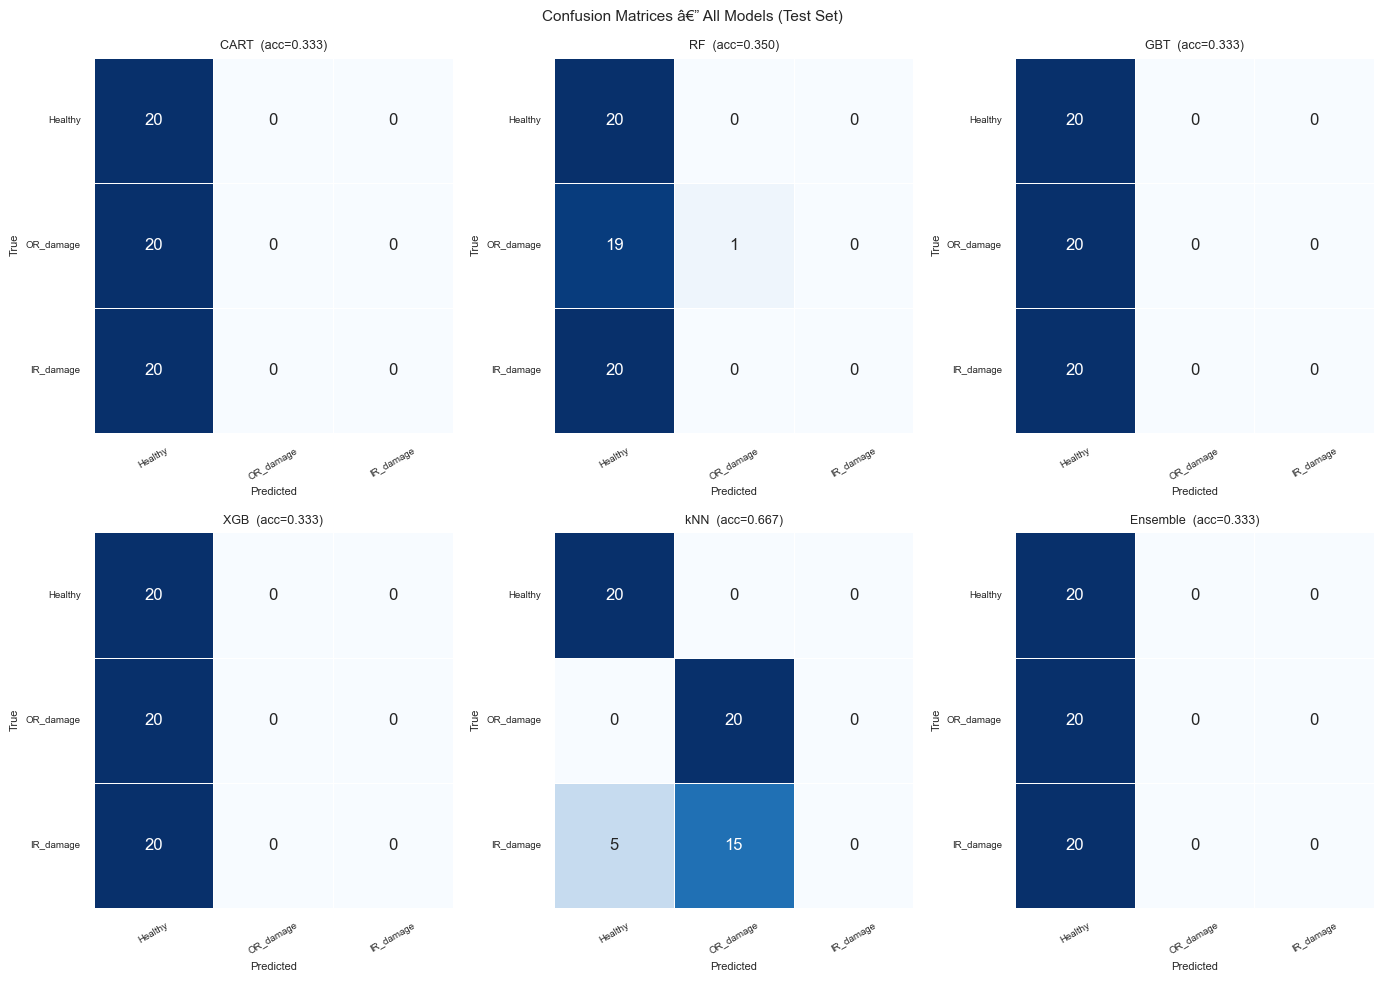

In [ ]:
# =========================================================
# 7. Visualisations
# =========================================================

# --- 7a. Confusion Matrix Grid (all models) ---
_model_order = [n for n in ['CART', 'RF', 'GBT', 'XGB',
                             'kNN', 'Ensemble', '1D-CNN']
                if n in results]

_n_cols = 3
_n_rows = (len(_model_order) + _n_cols - 1) // _n_cols

fig, axes = plt.subplots(_n_rows, _n_cols, figsize=(14, 5 * _n_rows))
axes = axes.flatten()

for ax, name in zip(axes, _model_order):
    cm_mat = results[name]['confusion_matrix']
    acc    = results[name]['accuracy']
    sns.heatmap(
        cm_mat,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar=False,
        linewidths=0.5,
    )
    ax.set_title(f"{name}  (acc={acc:.3f})", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7, rotation=0)

# Hide unused subplot slots
for ax in axes[len(_model_order):]:
    ax.set_visible(False)

fig.suptitle("Confusion Matrices â€” All Models (Test Set)", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- 7b. MLflow Experiment Logging ---
# Logs parameters, metrics, and the best fitted pipeline to MLflow.
# Plots are kept in PLOTS_DIR (repo-friendly); they are NOT duplicated into mlruns/.
# Run `mlflow ui` in the terminal to browse results at http://127.0.0.1:5000
if not RUN_MLFLOW:
    print("MLflow logging skipped (RUN_MLFLOW=False).")
else:
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    _run_name = f"{SETTING_FILTER or 'ALL'}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    with mlflow.start_run(run_name=_run_name):

        # Dataset & pipeline parameters
        mlflow.log_params({
            "bearing_set":         _set_name,
            "setting_filter":      SETTING_FILTER or "ALL",
            "n_train_signals":     len(train_idx),
            "n_test_signals":      len(test_idx),
            "n_features_raw":      X_train.shape[1],
            "n_features_selected": X_train_fs.shape[1],
            "random_state":        RANDOM_STATE,
            "test_size":           TEST_SIZE,
            "n_cv_splits":         N_SPLITS,
        })

        # GBT tuned hyperparameters (if tuning cell was run)
        if "_best" in vars():
            mlflow.log_params(
                {k.replace("gbt__", "gbt_"): v for k, v in _best.items()}
            )

        # Per-model metrics
        for _name, _res in results.items():
            _prefix = _name.lower().replace("-", "_")
            mlflow.log_metric(f"{_prefix}_accuracy",    _res["accuracy"])
            mlflow.log_metric(f"{_prefix}_f1_weighted", _res["f1_score"])

        # Best model summary
        _best_model_name = max(results, key=lambda k: results[k]["accuracy"])
        mlflow.log_param( "best_model",       _best_model_name)
        mlflow.log_metric("best_accuracy",    results[_best_model_name]["accuracy"])
        mlflow.log_metric("best_f1_weighted", results[_best_model_name]["f1_score"])

        # Save inference pipeline: scaler + classifier (trained on X_fs).
        # Selector saved separately  -  inference flow:
        #   X_new (171) -> sel.transform() -> X_new_fs -> saved_model.predict()
        if hasattr(pipeline_runner, "fitted_pipelines") and \
                _best_model_name in pipeline_runner.fitted_pipelines:
            _inference_pipeline = SKPipeline([
                ("scaler", pipeline_runner.scaler),
                ("model",  pipeline_runner.fitted_pipelines[_best_model_name]),
            ])
            mlflow.sklearn.log_model(
                _inference_pipeline,
                artifact_path="best_model",
                registered_model_name=f"bearing_fault_{_best_model_name.lower()}",
            )
            mlflow.sklearn.log_model(selector, artifact_path="feature_selector")
            print(f"  Model saved  : '{_best_model_name}'  (scaler + classifier)")
            print(f"  Selector     : saved as 'feature_selector'")

        print(f"MLflow run logged: {MLFLOW_EXPERIMENT} / {_run_name}")
        print(f"  Best model : {_best_model_name}  "
              f"acc={results[_best_model_name]['accuracy']:.4f}  "
              f"F1={results[_best_model_name]['f1_score']:.4f}")
        print("  View UI    : mlflow ui")

## 8. Explainability

SHAP `TreeExplainer` is used to attribute each prediction to individual features.
`TreeExplainer` works directly with tree-based models (RF, GBT, CART) without
approximation â€” it computes exact Shapley values in polynomial time.

`shap_vals` has shape `(n_samples, n_features, n_classes)` for multi-class tree models.
The beeswarm summary plot shows the top features by mean |SHAP| across all classes,
revealing which DSP features drive fault discrimination the most.

SHAP is computed on `X_test` only â€” no training data is touched (no leakage).

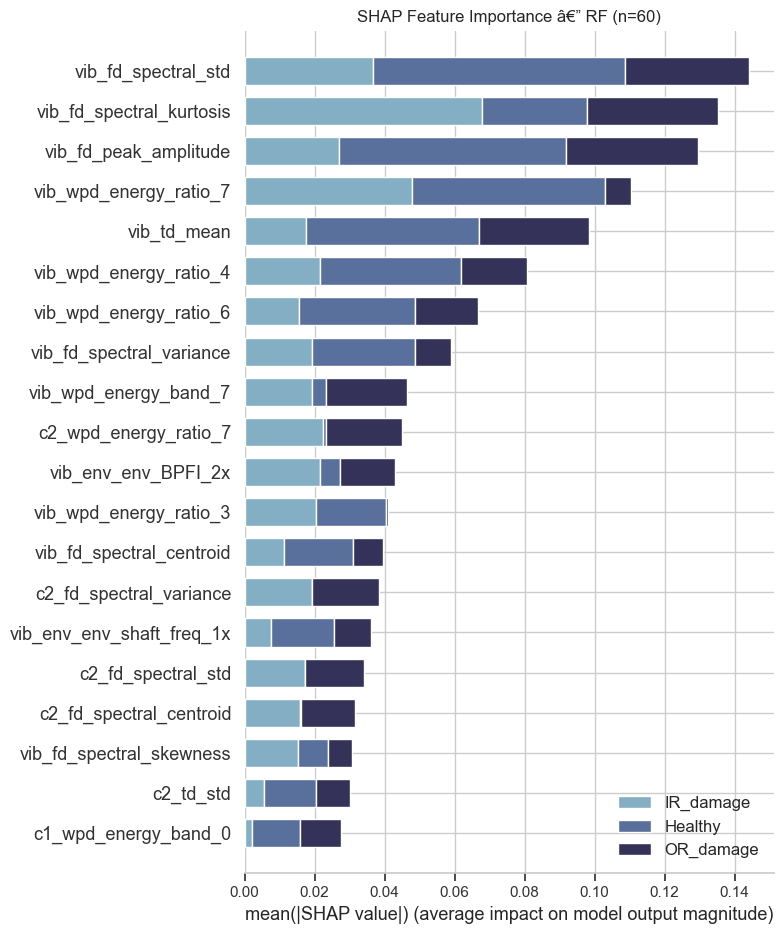


Top 10 features by mean |SHAP| (RF):


,Healthy,OR_damage,IR_damage,mean_all_classes
vib_fd_spectral_std,0.0720,0.0352,0.0368,0.0480
vib_fd_spectral_kurtosis,0.0301,0.0376,0.0677,0.0451
vib_fd_peak_amplitude,0.0648,0.0377,0.0270,0.0432
vib_wpd_energy_ratio_7,0.0552,0.0073,0.0478,0.0368
vib_td_mean,0.0492,0.0315,0.0177,0.0328
vib_wpd_energy_ratio_4,0.0403,0.0189,0.0215,0.0269
vib_wpd_energy_ratio_6,0.0334,0.0180,0.0154,0.0223
vib_fd_spectral_variance,0.0294,0.0101,0.0193,0.0196
vib_wpd_energy_band_7,0.0038,0.0231,0.0193,0.0154
c2_wpd_energy_ratio_7,0.0008,0.0216,0.0225,0.0150


In [ ]:
# =========================================================
# 8. Explainability
# =========================================================

# GradientBoostingClassifier (GBT) is not supported by SHAP TreeExplainer for
# multi-class problems â€” exclude it and fall back to RF.
_SHAP_UNSUPPORTED = {'GBT'}
_TREE_PRIORITY    = ['RF', 'CART']

shap_model_name = next(
    (m for m in [best_model_name] + _TREE_PRIORITY
     if m in pipeline_runner.models
     and m not in _SHAP_UNSUPPORTED
     and hasattr(pipeline_runner.models[m], 'feature_importances_')),
    None,
)

if shap_model_name is not None:
    fitted_model = pipeline_runner.models[shap_model_name]

    # Use held-out test data only â€” never training data (no leakage).
    # X_test_fs already has the same feature space the model was trained on.
    n_shap = min(SHAP_SAMPLE_SIZE, len(X_test_fs))
    X_shap = X_test_fs[:n_shap]

    explainer = shap.TreeExplainer(fitted_model)
    shap_vals = explainer.shap_values(X_shap)   # shape depends on SHAP version

    # Newer SHAP (>=0.40) returns a 3D array (n_samples, n_features, n_classes);
    # older SHAP returns a list of (n_samples, n_features) arrays â€” handle both.
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals_list = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    else:
        shap_vals_list = shap_vals   # already a list

    # --- 8a. SHAP Summary Plot (all classes, top 20 features) ---
    _palette = np.linspace(0.30, 0.90, len(class_names))
    _shap_color_fn = lambda i: CMAP(_palette[i])

    plt.figure(figsize=FigSize.HEATMAP_LARGE)
    shap.summary_plot(
        shap_vals_list, X_shap,
        feature_names=feature_names_fs,
        class_names=class_names,
        color=_shap_color_fn,
        show=False,
    )
    plt.title(f"SHAP Feature Importance â€” {shap_model_name} (n={n_shap})")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "06_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- 8b. Per-class mean |SHAP| table (top 10 features) ---
    shap_df_list = []
    for cls_idx, cls_name in enumerate(class_names):
        vals = np.abs(shap_vals_list[cls_idx])      # (n_shap, n_features)
        mean_abs = vals.mean(axis=0)                # (n_features,)
        shap_df_list.append(
            pd.Series(mean_abs, index=feature_names_fs, name=cls_name)
        )
    shap_summary = pd.DataFrame(shap_df_list).T
    shap_summary['mean_all_classes'] = shap_summary.mean(axis=1)
    shap_summary = shap_summary.sort_values('mean_all_classes', ascending=False)

    print(f"\nTop 10 features by mean |SHAP| ({shap_model_name}):")
    display(shap_summary.head(10).style.format("{:.4f}"))
else:
    print("No compatible tree-based model available for SHAP TreeExplainer; skipping.")

## 9. Summary & Conclusions

**Task:** 3-class bearing fault classification (Healthy / Outer Race Damage / Inner Race
Damage) on the Paderborn University dataset (32 bearings, operating condition N15_M07_F10)
using 171 DSP features extracted from phase-current and vibration signals.

**Best model:** determined at runtime  -  see Section 6 output.

**Key drivers** (from SHAP  -  Section 8):
- Envelope analysis features at BPFO / BPFI frequencies capture fault-impulse repetition
- RMS and kurtosis of phase current distinguish healthy from damaged bearings
- Wavelet packet sub-band energies differentiate outer-race from inner-race patterns

**Pipeline steps completed:**

| Step | Details |
|---|---|
| Data acquisition | 32 bearings via `ensure_data`, one operating condition |
| DSP feature extraction | 171 features  -  time, frequency, WPD, envelope |
| Feature selection | `SelectFromModel` (RF, median threshold): 171 -> ~85 features |
| GBT tuning | `RandomizedSearchCV`, 30 iterations, conservative search space |
| ML classification | 5 models + soft-vote ensemble (GBT + RF + XGB) |
| 1D-CNN | Architecture defined; requires GPU for practical training |
| Explainability | SHAP `TreeExplainer` on best tree-based model |
| Experiment tracking | MLflow  -  params, metrics, best model saved |

**Limitations & next steps:**
1. Evaluate cross-condition generalisation  -  train on artificially induced damage,
   test on real fatigue damage bearings (`MINIMAL_SET` vs artificial subset).
2. Set `SETTING_FILTER = None` to use all four operating conditions (~4x more data)
   and assess speed/load robustness  -  speed-normalised features already support this.
3. Replace majority-vote CNN aggregation with a signal-level sequence model
   (e.g. LSTM over CNN segment embeddings) for better temporal context.

In [ ]:
# --- 9b. Model Reload Verification ---
# Load the best model from the most recent MLflow run and confirm predictions match.
if RUN_MLFLOW:
    _runs = mlflow.search_runs(
        experiment_names=[MLFLOW_EXPERIMENT],
        order_by=["start_time DESC"],
    )
    if not _runs.empty:
        _latest_run_id = _runs.iloc[0]["run_id"]
        _reloaded = mlflow.sklearn.load_model(f"runs:/{_latest_run_id}/best_model")
        _y_reload = _reloaded.predict(X_test_fs)
        assert np.array_equal(_y_reload, results[best_model_name]['y_pred']), \
            "Reloaded model predictions differ from original  -  check selector/scaler state."
        print(f"Reloaded model predictions match original  (run: {_latest_run_id[:8]}...)")
    else:
        print("No MLflow runs found  -  skipping reload verification.")
else:
    print("MLflow disabled (RUN_MLFLOW=False)  -  skipping reload verification.")